In [3]:
#import libraries
import torch 
import torch.nn as nn 
import torch.optim as optim
from torchvision import datasets,  transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt



In [4]:
device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [58]:
#data into train and val 
BATCH_SIZE = 128
data_transform = transforms.Compose([transforms.ToTensor()])

#train_dataset = datasets.MNIST(root= "./data",  train= True, transform= data_transform, download=True)
train_dataset = datasets.FashionMNIST(root= "./data",  train= True, transform= data_transform, download=True)
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)

100%|██████████| 26.4M/26.4M [00:12<00:00, 2.09MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 179kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.32MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.85MB/s]


In [66]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim = 32, hidden_dim = 256):
        super().__init__()
    #encoder
        self.encoder = nn.Sequential(
            nn.Linear(784,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()

        )
    #Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 784),
            nn.Sigmoid()

        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon
    


In [67]:
#defining the model, loss
model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [68]:
epochs =5
model.train()
for epoch in range(epochs):
    total_loss = 0
    for x,_ in train_loader:
        x = x.view(-1,784).to(device)
        optimizer.zero_grad()
 
        x_recon = model(x)
        loss = criterion(x_recon,x)
        loss.backward()
        optimizer.step()
        total_loss+= loss.item()
    avg_loss = total_loss/len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}],Loss:{avg_loss:.6f}")

Epoch [1/5],Loss:0.033677
Epoch [2/5],Loss:0.017944
Epoch [3/5],Loss:0.015535
Epoch [4/5],Loss:0.014250
Epoch [5/5],Loss:0.013417


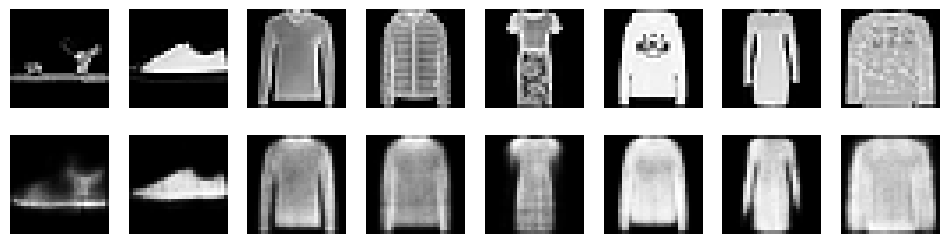

In [71]:
model.eval()
with torch.no_grad():
    x,_=next(iter(train_loader))
    x = x.view(-1,784).to(device)
    x_recon =model(x)
    x = x.cpu()
    n = 8 
    plt.figure(figsize =(12,3))
    for i in range(n):
        plt.subplot(2,n,i+1)
        plt.imshow(x[i].view(28,28),cmap="gray")
        plt.axis("off")

        plt.subplot(2,n,i+1+n)
        plt.imshow(x_recon[i].view(28,28), cmap="gray")
        plt.axis("off")
    plt.show()

In [63]:
model.eval()
latents = []
labels=[]
with torch.no_grad():
    for x,y in train_loader:
        x = x.view(-1,784).to(device)
        z= model.encoder(x)
        latents.append(z.cpu())
        labels.append(y)
latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

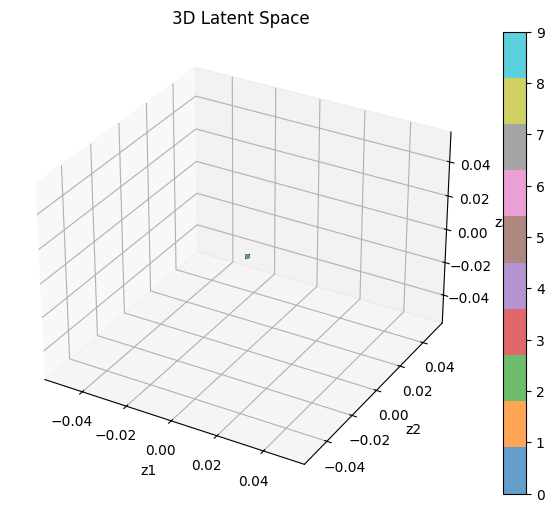

In [64]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


latent_dim = latents.shape[1]
Z=latents.detach().cpu().numpy()
y=labels.detach().cpu().numpy()

if latent_dim ==1:
    plt.figure(figsize=(8,4))
    for digit in range(10):
        plt.hist(
            Z[y == digit].flatten(),
            bins=50,
            alpha =0.5,
            label=str(digit)
        )
    plt.xlabel("Latent value")
    plt.ylabel("Frequency")
    plt.title("1D Latent Distribution by Class")
    plt.legend()
    plt.show()

    plt.Figure(figsize=(8,3))
    plt.scatter(Z.flatten(), y, s=5, alpha=0.5)
    plt.xlabel("Latent value")
    plt.ylabel("Digit class")
    plt.title("1D Latent Strip Plot")
    plt.show()
elif latent_dim==2:
    #-----2D Scatter---
    plt.Figure(figsize=(8,6))
    scatter = plt.scatter(
        Z[:,0],Z[:,1],
        c=y, cmap="tab10",
        s=5, alpha=0.7
    )
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("2D Latent Space")
    plt.show()
elif latent_dim == 3:
    #---3D Rotatable Scatter--
    fig = plt.figure(figsize=(8,6))
    ax= fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(
        Z[:,0], Z[:,1],Z[:,2],
        c=y, cmap="tab10",
        s=5, alpha=0.7
    )
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_zlabel("z3")
    ax.set_title("3D Latent Space")
    fig.colorbar(scatter, ticks= range(10))
    plt.show()
else:
    #----->3D:PCA projection––––
    #pca_dim=3 if latent_dim >=3 else 2
    pca_dim=2
    pca = PCA(n_components=pca_dim)
    Z_pca = pca.fit_transform(Z)
    if pca_dim==2:
        plt.Figure(figsize=(8,6))
        scatter=plt.scatter(
            Z_pca[:,0],Z_pca[:,1],
            c=y, cmap="tab10",
            s=5, alpha=0.7
        )
        plt.colorbar(scatter, ticks=range(10))
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("PCA Projection of Latent Space(>3D)")
        plt.show()
    else:
        fig = plt.Figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection="3d")
        scatter = ax.scatter(
            Z_pca[:,0], Z_pca[:,1], Z_pca[:,2],
            c=y, cmap="tab10",
            s=5, alpha =0.7
        )
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.set_title("3D PCA Projection of LAtent Space(>3D)")
        fig.colorbar(scatter, tricks = range(10))
        plt.show()

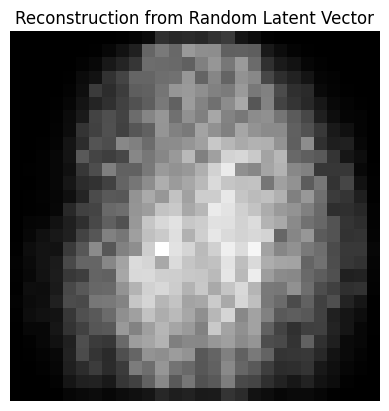

In [65]:
model.eval()
with torch.no_grad():
    latent_dim = model.encoder[-2].out_features
    z_random = torch.randn(1, latent_dim).to(device)
    x_generated = model.decoder(z_random)
    x_generated=x_generated.cpu().view(28,28)
plt.Figure(figsize=(3,3))
plt.imshow(x_generated, cmap="gray")
plt.axis("off")
plt.title("Reconstruction from Random Latent Vector")
plt.show()